## Data Preprocessing

5 minute price data for the past 2 years was retrieved from Alpaca Markets (https://alpaca.markets/). 

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplfinance as mpf

In [2]:
# load 5M price data for each stock
files = {
    "COIN": "COIN_5min_2yr.csv",
    "NVDA": "NVDA_5min_2yr.csv",
    "OKLO": "OKLO_5min_2yr.csv",
    "PLTR": "PLTR_5min_2yr.csv",
    "TSLA": "TSLA_5min_2yr.csv",
}

# combine all 5 stock price data into one df
dfs = []
for sym, path in files.items():
    d = pd.read_csv(path, parse_dates=["timestamp"])
    d["symbol"] = sym
    dfs.append(d)

raw = pd.concat(dfs, ignore_index=True)

print("Combined shape:", raw.shape)
print("Symbols:", raw["symbol"].value_counts())
print(raw.head())
print(raw.tail())

Combined shape: (401473, 9)
Symbols: symbol
NVDA    81536
TSLA    81536
PLTR    81523
COIN    81506
OKLO    75372
Name: count, dtype: int64
  symbol                 timestamp     open      high     low     close  \
0   COIN 2024-02-28 17:00:00+00:00  210.435  211.2000  208.38  211.2000   
1   COIN 2024-02-28 17:05:00+00:00  211.166  211.6300  210.38  210.8750   
2   COIN 2024-02-28 17:10:00+00:00  210.770  211.1950  209.25  211.0379   
3   COIN 2024-02-28 17:15:00+00:00  211.040  211.4599  207.80  207.8900   
4   COIN 2024-02-28 17:20:00+00:00  207.960  209.0000  206.50  206.7100   

     volume  trade_count        vwap  
0  434465.0       5272.0  209.858263  
1  238866.0       4011.0  211.133156  
2  258458.0       3356.0  210.383626  
3  296406.0       4428.0  209.852641  
4  334472.0       4715.0  207.499718  
       symbol                 timestamp    open     high     low     close  \
401468   TSLA 2026-02-27 16:25:00+00:00  402.71  402.900  402.00  402.2800   
401469   TSLA 2026-

### Data Cleaning & Exploratory Data Analysis

In [3]:
# filter for only active trading hours 9:30 - 4PM Eastern Time
REGULAR_SESSION_ONLY = True
TZ_LOCAL = "America/New_York"

df = raw.copy()

# check timestamps
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
bad_ts = df["timestamp"].isna().sum()
if bad_ts:
    print("bad timestamps:", bad_ts)

# convert to eastern time
df["ts_ny"] = df["timestamp"].dt.tz_convert(TZ_LOCAL)

# sort by stock and timestamp
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# ensure we don't have duplicates
dup = df.duplicated(subset=["symbol", "timestamp"]).sum()
print("duplicate (symbol,timestamp):", dup)
if dup:
    df = df.drop_duplicates(subset=["symbol", "timestamp"], keep="last").reset_index(drop=True)

# filter for active trading hours 9:30 - 16:00
df["date_ny"] = df["ts_ny"].dt.date
df["time_ny"] = df["ts_ny"].dt.time

if REGULAR_SESSION_ONLY:
    t = df["ts_ny"].dt.time
    mask = (t >= pd.to_datetime("09:30").time()) & (t <= pd.to_datetime("15:55").time())
    before = len(df)
    df = df.loc[mask].reset_index(drop=True)
    print(f"regular session rows kept: {len(df)} / {before}")

# check date range
print("min timestamp:", df["timestamp"].min())
print("max timestamp:", df["timestamp"].max())

duplicate (symbol,timestamp): 0
regular session rows kept: 171812 / 401473
min timestamp: 2024-02-28 16:50:00+00:00
max timestamp: 2026-02-27 16:55:00+00:00


For Regular Trading Hours, the last regular trading session bar is at 3:55 PM Eastern Time. The 4PM bar would be after hours, so price data is extracted from 9:30 AM to 3:55PM

In [4]:
# check price data completeness for each stock
day_coverage = (
    df.groupby(["symbol", "date_ny"])["ts_ny"]
      .agg(first="min", last="max", bars="count")
      .reset_index()
)
print(day_coverage.head(5))
print(day_coverage.tail(5))

# regular trading hours has about 78 5 minute candles
fullish = day_coverage["bars"] >= 75

print("\nFull trading days per stock:")
print(day_coverage.groupby("symbol")["bars"].apply(lambda s: (s >= 75).sum()).sort_values(ascending=False))
print("\nTotal full trading day rows:", fullish.sum(), "out of", len(day_coverage))

  symbol     date_ny                     first                      last  bars
0   COIN  2024-02-28 2024-02-28 12:00:00-05:00 2024-02-28 15:55:00-05:00    48
1   COIN  2024-02-29 2024-02-29 09:30:00-05:00 2024-02-29 15:55:00-05:00    78
2   COIN  2024-03-01 2024-03-01 09:30:00-05:00 2024-03-01 15:55:00-05:00    78
3   COIN  2024-03-04 2024-03-04 09:30:00-05:00 2024-03-04 15:55:00-05:00    78
4   COIN  2024-03-05 2024-03-05 09:30:00-05:00 2024-03-05 15:55:00-05:00    78
     symbol     date_ny                     first                      last  \
2233   TSLA  2026-02-23 2026-02-23 09:30:00-05:00 2026-02-23 15:55:00-05:00   
2234   TSLA  2026-02-24 2026-02-24 09:30:00-05:00 2026-02-24 15:55:00-05:00   
2235   TSLA  2026-02-25 2026-02-25 09:30:00-05:00 2026-02-25 15:55:00-05:00   
2236   TSLA  2026-02-26 2026-02-26 09:30:00-05:00 2026-02-26 15:55:00-05:00   
2237   TSLA  2026-02-27 2026-02-27 09:30:00-05:00 2026-02-27 11:45:00-05:00   

      bars  
2233    78  
2234    78  
2235    78  

It's important to note that the total number of full trading days is counting across all 5 stocks. This is not unique trading days across the market.

To visualize financial data, the following mplfinance package will be utilized.

https://github.com/matplotlib/mplfinance

In [5]:
# function to plot 2 year price data as candle stick charts
def plot_daily(symbol, df):
    d = df[df["symbol"] == symbol].copy()
    d["ts_ny"] = pd.to_datetime(d["ts_ny"])
    d = d.set_index("ts_ny").sort_index()
    daily = d.resample("1D").agg({
        "open": "first",
        "high": "max",
        "low": "min",
        "close": "last",
        "volume": "sum"
    }).dropna()

    mc = mpf.make_marketcolors(up="green", down="red", edge="inherit", wick="inherit", volume="inherit")
    style = mpf.make_mpf_style(marketcolors=mc, gridstyle="-")

    mpf.plot(
        daily, type="candle", volume=True, style=style,
        title=f"{symbol} — Daily (Regular Trading Hours Only)",
        ylabel="Price", ylabel_lower="Volume", figsize=(14, 7), tight_layout=True
    )

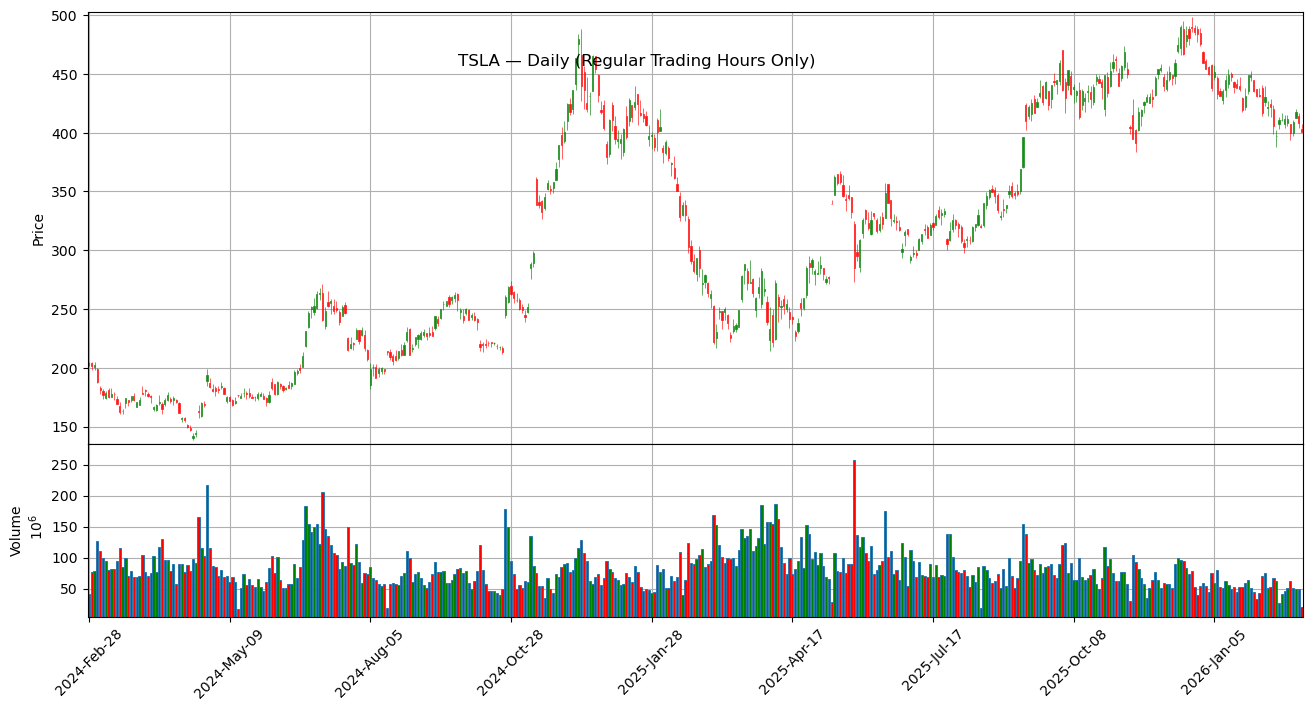

In [6]:
plot_daily("TSLA", df)

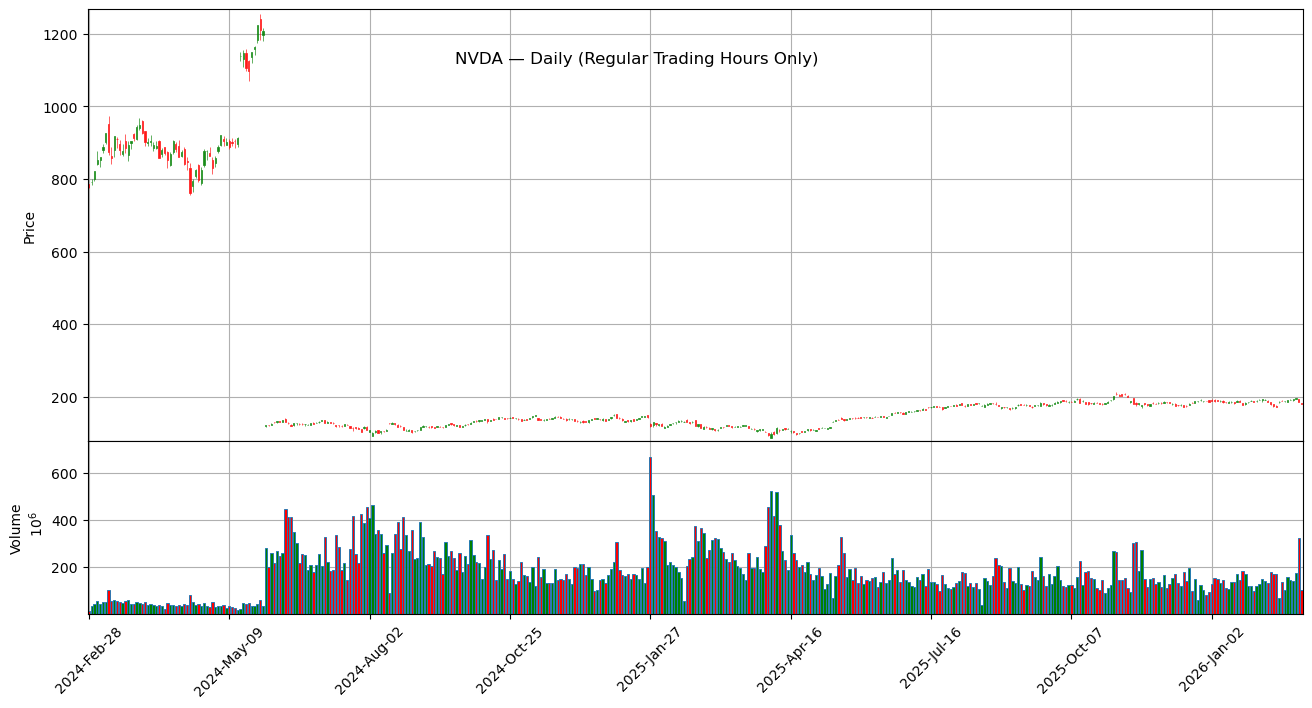

In [7]:
plot_daily("NVDA", df)

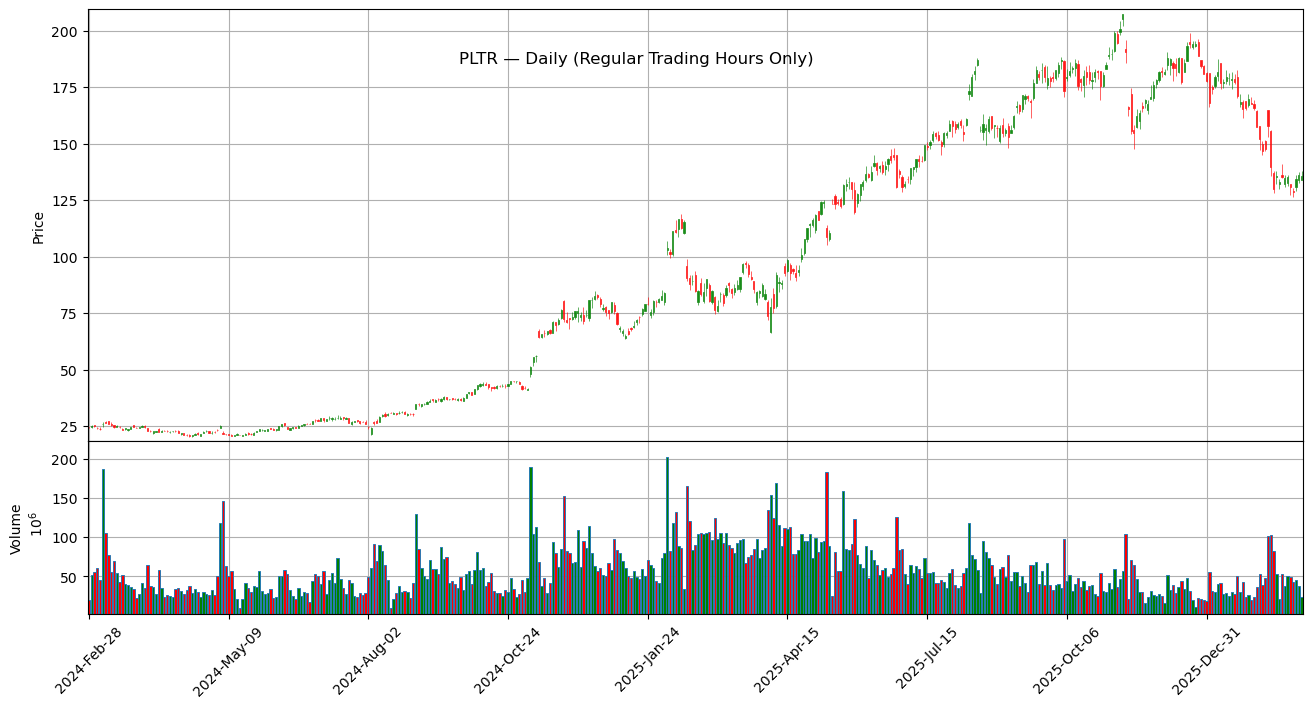

In [8]:
plot_daily("PLTR", df)

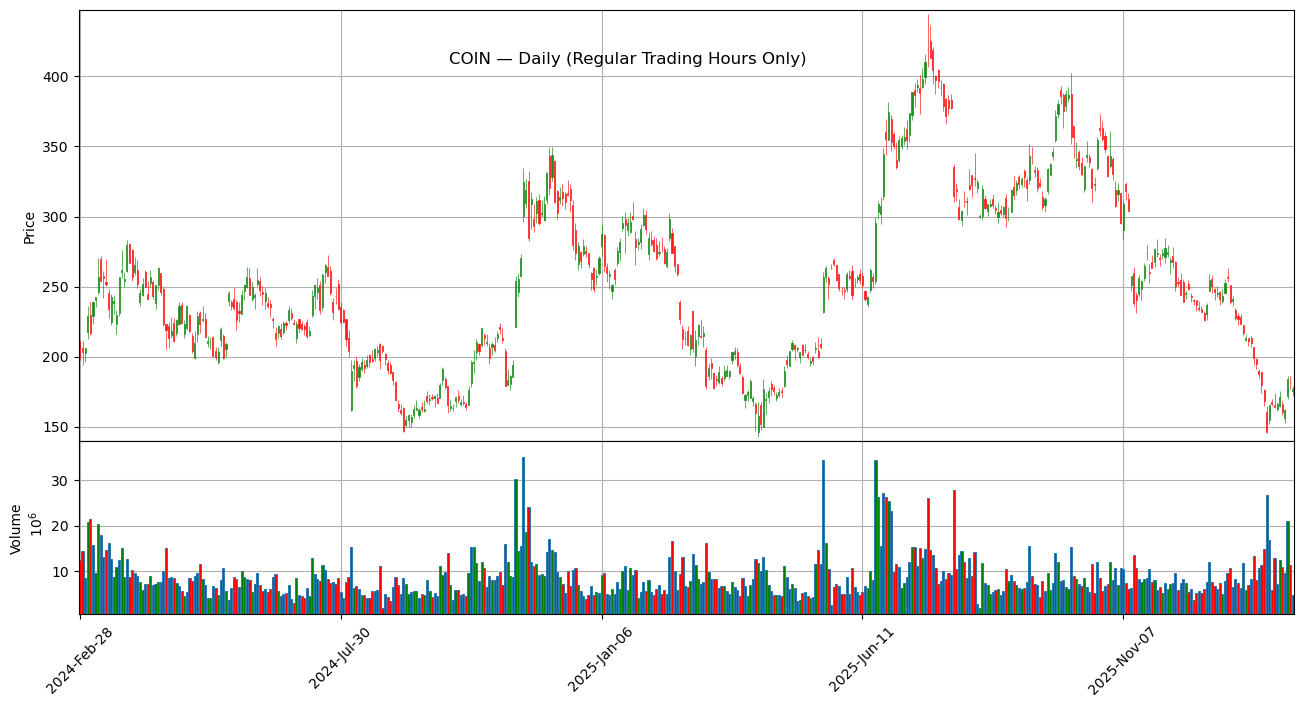

In [9]:
plot_daily("COIN", df)

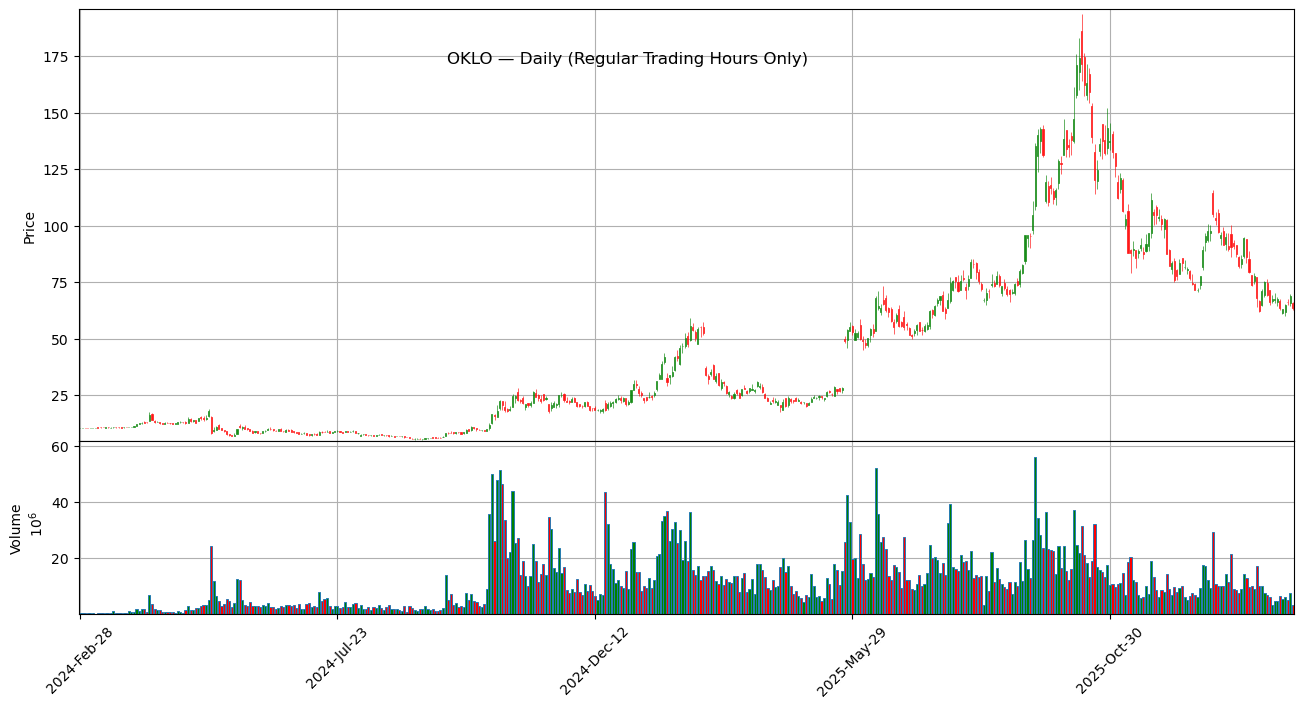

In [10]:
plot_daily("OKLO", df)

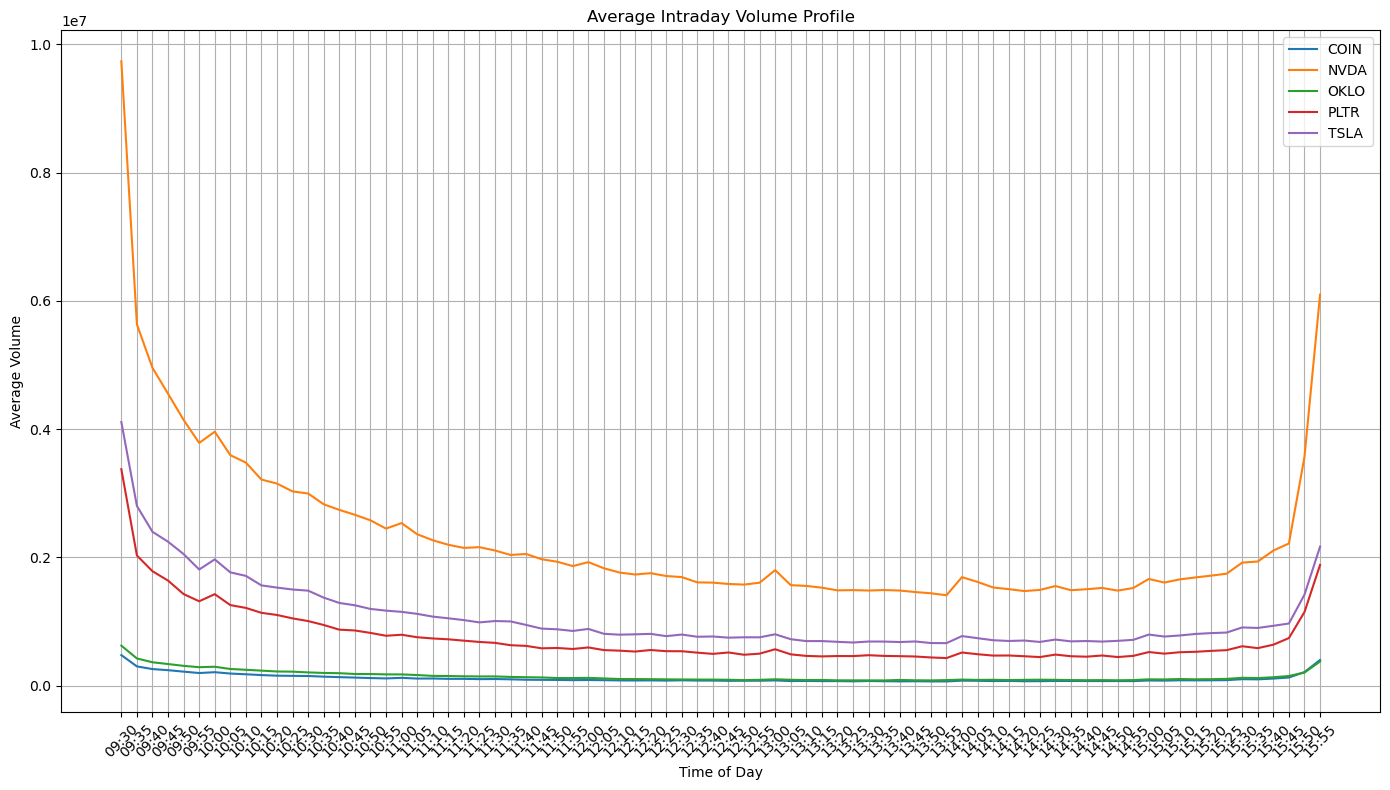

In [11]:
# visualize volume profile by time of day across stocks
temp = df.copy()
temp["minute_slot"] = temp["ts_ny"].dt.strftime("%H:%M")

avg_vol = (
    temp.groupby(["symbol", "minute_slot"])["volume"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 8))
for sym in sorted(avg_vol["symbol"].unique()):
    d = avg_vol[avg_vol["symbol"] == sym]
    plt.plot(d["minute_slot"], d["volume"], label=sym)

plt.title("Average Intraday Volume Profile")
plt.xlabel("Time of Day")
plt.ylabel("Average Volume")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

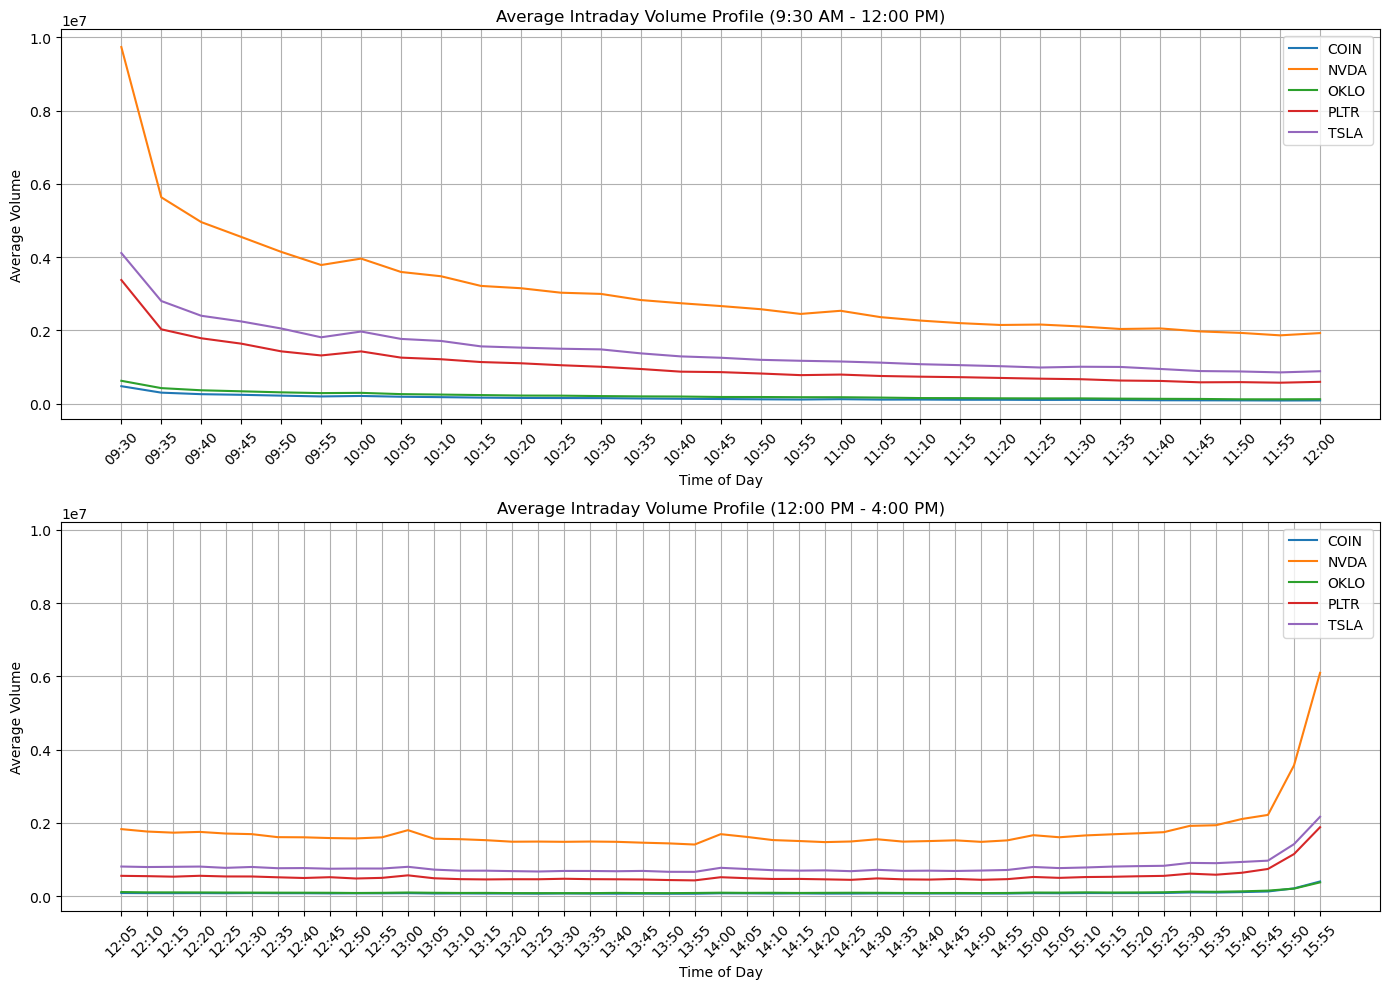

In [12]:
# split volume profile plot for visibility
# visualize volume profile by time of day across stocks
temp = df.copy()
temp["minute_slot"] = temp["ts_ny"].dt.strftime("%H:%M")

avg_vol = (
    temp.groupby(["symbol", "minute_slot"])["volume"]
    .mean()
    .reset_index()
)

# split into morning and afternoon sessions
morning = avg_vol[
    (avg_vol["minute_slot"] >= "09:30") & (avg_vol["minute_slot"] <= "12:00")
].copy()

afternoon = avg_vol[
    (avg_vol["minute_slot"] > "12:00") & (avg_vol["minute_slot"] <= "16:00")
].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharey=True)

# morning subplot
for sym in sorted(morning["symbol"].unique()):
    d = morning[morning["symbol"] == sym]
    axes[0].plot(d["minute_slot"], d["volume"], label=sym)

axes[0].set_title("Average Intraday Volume Profile (9:30 AM - 12:00 PM)")
axes[0].set_xlabel("Time of Day")
axes[0].set_ylabel("Average Volume")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# afternoon subplot
for sym in sorted(afternoon["symbol"].unique()):
    d = afternoon[afternoon["symbol"] == sym]
    axes[1].plot(d["minute_slot"], d["volume"], label=sym)

axes[1].set_title("Average Intraday Volume Profile (12:00 PM - 4:00 PM)")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Average Volume")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# save cleaned 5M RTH dataset
rth_cols = [
    "symbol","timestamp","date_ny",
    "open","high","low","close","volume","trade_count","vwap"
]

df_rth = df[rth_cols].copy()

df_rth.to_csv("multiasset_5m_rth_only.csv", index=False)

print("Saved: multiasset_5m_rth_only.csv")
print("Rows:", len(df_rth))
print("\nRows per symbol:")
print(df_rth["symbol"].value_counts())

Saved: multiasset_5m_rth_only.csv
Rows: 171812

Rows per symbol:
symbol
COIN    35876
OKLO    35782
PLTR    33489
NVDA    33355
TSLA    33310
Name: count, dtype: int64


## Feature Engineering

Calculate price action indicators in preparation for generating entry and exits

The indicators will be:
- VWAP: Volume Weighted Average Price 
- ATR: Average True Range   - measures market volatility
- Returns: Gains and Losses
- Range: Price difference between High of Day and Low of Day
- Volume Impulse: Sudden increases in trading volume - significant price moves
- Realized Volatility: Measures actual price fluctuations (historical) 
- Time of Day

In [13]:
# ensure price data is sorted by stock
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# calculate session VWAP
tp = (df["high"] + df["low"] + df["close"]) / 3.0
pv = tp * df["volume"]

df["vwap_session"] = (
    pv.groupby([df["symbol"], df["date_ny"]]).cumsum()
    / df["volume"].groupby([df["symbol"], df["date_ny"]]).cumsum()
)

# Average True Range (ATR)
prev_close = df.groupby("symbol")["close"].shift(1)

tr = pd.concat(
    [(df["high"] - df["low"]).abs(),
     (df["high"] - prev_close).abs(),
     (df["low"] - prev_close).abs(),
    ],axis=1,).max(axis=1)

# use 12 for 2 hours
df["atr_12"] = tr.groupby(df["symbol"]).rolling(12, min_periods=12).mean().reset_index(level=0, drop=True)
df["atr_pct_12"] = df["atr_12"] / df["close"]

# 5 minute, 15 minute, 30 minute, 60 minute, 90 minute, 120 minute returns
df["ret_1"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(1))
df["ret_3"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(3))
df["ret_6"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(6))
df["ret_12"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(12))
df["ret_18"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(18))
df["ret_24"] = np.log(df["close"] / df.groupby("symbol")["close"].shift(24))

# Range
df["range_pct"] = (df["high"] - df["low"]) / df["close"]
df["body_pct"] = (df["close"] - df["open"]).abs() / df["close"]
df["upper_wick_pct"] = (df["high"] - df[["open", "close"]].max(axis=1)) / df["close"]
df["lower_wick_pct"] = (df[["open", "close"]].min(axis=1) - df["low"]) / df["close"]

# VWAP distance
df["vwap_dist"] = (df["close"] - df["vwap_session"]) / df["close"]
df["vwap_dist_atr"] = (df["close"] - df["vwap_session"]) / df["atr_12"]

# Volume impulse, 90 minutes of data
vol_ma18 = df.groupby("symbol")["volume"].rolling(18, min_periods=18).mean().reset_index(level=0, drop=True)
df["vol_ratio_18"] = df["volume"] / vol_ma18

# Realized volatility, 60 minutes
df["rv_12"] = df.groupby("symbol")["ret_1"].rolling(12, min_periods=12).std().reset_index(level=0, drop=True)

# Time of Day for cyclical  patterns
minutes = df["ts_ny"].dt.hour * 60 + df["ts_ny"].dt.minute
session_start = 9 * 60 + 30
x = (minutes - session_start) / 390.0

# sine/cosine for circular representation of time
df["tod_sin"] = np.sin(2 * np.pi * x)
df["tod_cos"] = np.cos(2 * np.pi * x)

In [14]:
# check for missing features
feature_cols = [
    "vwap_session","atr_12","atr_pct_12",
    "ret_1","ret_3","ret_6","ret_12","ret_18","ret_24",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "vwap_dist","vwap_dist_atr",
    "vol_ratio_18","rv_12",
    "tod_sin","tod_cos"
]

print("NaNs total:")
print(df[feature_cols].isna().sum().sort_values(ascending=False).head(12))

print("\nNaNs per symbol:")
print(df.groupby("symbol")[feature_cols].apply(lambda x: x.isna().sum()).head())

NaNs total:
ret_24           120
ret_18            90
vol_ratio_18      85
ret_12            60
rv_12             60
vwap_dist_atr     55
atr_pct_12        55
atr_12            55
ret_6             30
ret_3             15
ret_1              5
vwap_session       0
dtype: int64

NaNs per symbol:
        vwap_session  atr_12  atr_pct_12  ret_1  ret_3  ret_6  ret_12  ret_18  \
symbol                                                                          
COIN               0      11          11      1      3      6      12      18   
NVDA               0      11          11      1      3      6      12      18   
OKLO               0      11          11      1      3      6      12      18   
PLTR               0      11          11      1      3      6      12      18   
TSLA               0      11          11      1      3      6      12      18   

        ret_24  range_pct  body_pct  upper_wick_pct  lower_wick_pct  \
symbol                                                            

Indicators with NaNs are expecting since they need rolling price data to be calculated

In [15]:
# check volume impulse summary stats
summary = (
    df.groupby("symbol")["vol_ratio_18"]
    .agg(["count","mean","median","std","min","max",]))
summary.columns = ["count", "mean", "median", "std", "min", "max"]

print(summary)

        count      mean    median       std       min        max
symbol                                                          
COIN    35859  1.047071  0.844302  0.777402  0.002765  17.645417
NVDA    33338  1.034964  0.876332  0.652692  0.009093  17.761691
OKLO    35765  1.050235  0.809251  0.896758  0.001197  17.660874
PLTR    33472  1.041693  0.863685  0.715178  0.001740  17.387294
TSLA    33293  1.033819  0.880899  0.628805  0.010266  17.242176


<Figure size 1000x600 with 0 Axes>

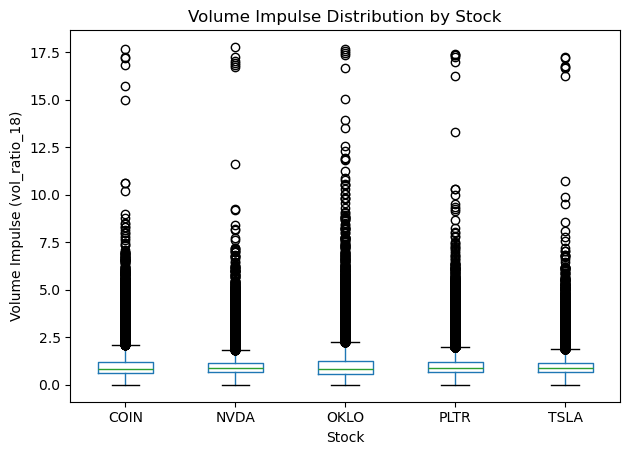

In [16]:
# check volume impulse distrubtion across stocks
plt.figure(figsize=(10, 6))
df.boxplot(column="vol_ratio_18", by="symbol", grid=False)
plt.title("Volume Impulse Distribution by Stock")
plt.suptitle("")
plt.xlabel("Stock")
plt.ylabel("Volume Impulse (vol_ratio_18)")
plt.tight_layout()
plt.show()

In [17]:
# save 5 minute RTH with features as csv
feature_cols = [
    "ret_1","ret_3","ret_6","ret_12","ret_18","ret_24",
    "atr_12","atr_pct_12",
    "vwap_session","vwap_dist","vwap_dist_atr",
    "vol_ratio_18",
    "range_pct","body_pct","upper_wick_pct","lower_wick_pct",
    "rv_12",
    "tod_sin","tod_cos"
]

base_cols = [
    "symbol","timestamp","date_ny",
    "open","high","low","close","volume","trade_count"
]

df_features = df[base_cols + feature_cols].copy()

# drop NaNs as file will be used for regimes
df_regimes = df_features.dropna().reset_index(drop=True)

df_regimes.to_csv("multiasset_5m_rth_features.csv", index=False)

print("Saved: multiasset_5m_rth_features.csv")
print("Total rows:", len(df_regimes))
print("\nRows per symbol after dropna:")
print(df_regimes["symbol"].value_counts())

Saved: multiasset_5m_rth_features.csv
Total rows: 171692

Rows per symbol after dropna:
symbol
COIN    35852
OKLO    35758
PLTR    33465
NVDA    33331
TSLA    33286
Name: count, dtype: int64


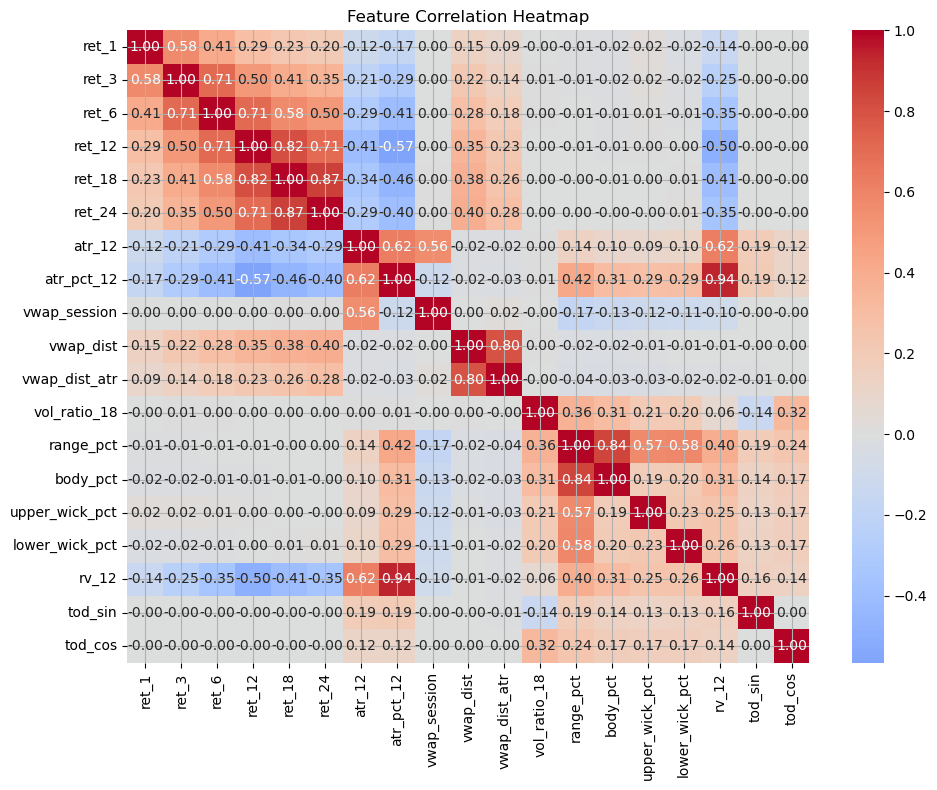

In [18]:
# visualize feature correlation heatmap
corr = df_regimes[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Entry Opportunities

Create entry signals based on the VWAP Reclaim Long Setup. If price reclaims VWAP with volume, long scalp trade opportunity.

Entry Signal:
- Long entry when price is below VWAP on the prior 5M bar and closes above VWAP on current bar
- Use volume as an indicator if price will continue to sustain upon reclaiming VWAP

The goal is to use this trade setup along with market regimes to determine whether or not utilizing market regimes to change trade parameters will yield stronger trade performance than fixed trade parameters. 

In [19]:
# VWAP Reclaim setup

# need volume and price to close above VWAP
VOL_IMPULSE = 1.5

prev_close = df.groupby("symbol")["close"].shift(1)
prev_vwap  = df.groupby("symbol")["vwap_session"].shift(1)

# setup signal
signal = (
    (prev_close < prev_vwap) &
    (df["close"] > df["vwap_session"]) &
    (df["vol_ratio_18"] >= VOL_IMPULSE) &
    (df["ret_1"] > 0)
)

# index signals
signal_idx = np.flatnonzero(signal.values)

# enter on next 5min candle
entry_idx = signal_idx + 1
valid = (entry_idx < len(df)) & (df.loc[signal_idx, "symbol"].values == df.loc[entry_idx, "symbol"].values)

signal_idx = signal_idx[valid]
entry_idx  = entry_idx[valid]

# create trade entry table
entries = pd.DataFrame({
    "symbol": df.loc[signal_idx, "symbol"].values,
    "i_signal": signal_idx,
    "i_entry": entry_idx,
    "ts_signal": df.loc[signal_idx, "timestamp"].values,
    "ts_entry": df.loc[entry_idx, "timestamp"].values,
    "entry_price": df.loc[entry_idx, "open"].values,
})

# confirm required features exist for trade simulation
needed_signal = ["atr_12", "vol_ratio_18", "vwap_session", "ret_1"]
needed_entry = ["atr_12"]

# remove rows with missing indicators
ok_signal = df.loc[entries["i_signal"], needed_signal].notna().all(axis=1).values
ok_entry  = df.loc[entries["i_entry"], needed_entry].notna().all(axis=1).values
entries = entries.loc[ok_signal & ok_entry].reset_index(drop=True)

print("Total entries found:", len(entries))
print("\nEntries by symbol:")
print(entries["symbol"].value_counts())

print("\nPreview:")
print(entries.head(5))

Total entries found: 1616

Entries by symbol:
symbol
OKLO    360
COIN    329
TSLA    319
NVDA    306
PLTR    302
Name: count, dtype: int64

Preview:
  symbol  i_signal  i_entry           ts_signal            ts_entry  \
0   COIN        48       49 2024-02-29 14:30:00 2024-02-29 14:35:00   
1   COIN       117      118 2024-02-29 20:15:00 2024-02-29 20:20:00   
2   COIN       283      284 2024-03-05 14:35:00 2024-03-05 14:40:00   
3   COIN       360      361 2024-03-06 14:30:00 2024-03-06 14:35:00   
4   COIN       578      579 2024-03-08 19:40:00 2024-03-08 19:45:00   

   entry_price  
0      209.720  
1      201.420  
2      233.650  
3      233.055  
4      257.810  


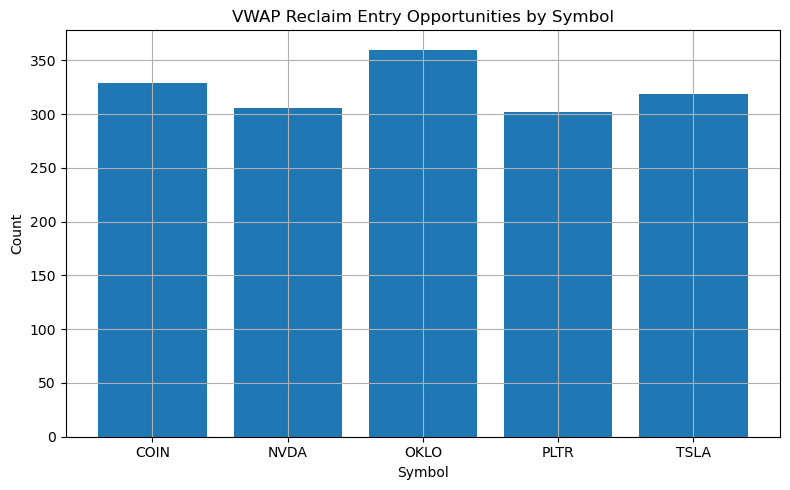

In [20]:
# visualize entries by stock
entry_counts = entries["symbol"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(entry_counts.index, entry_counts.values)
plt.title("VWAP Reclaim Entry Opportunities by Symbol")
plt.xlabel("Symbol")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

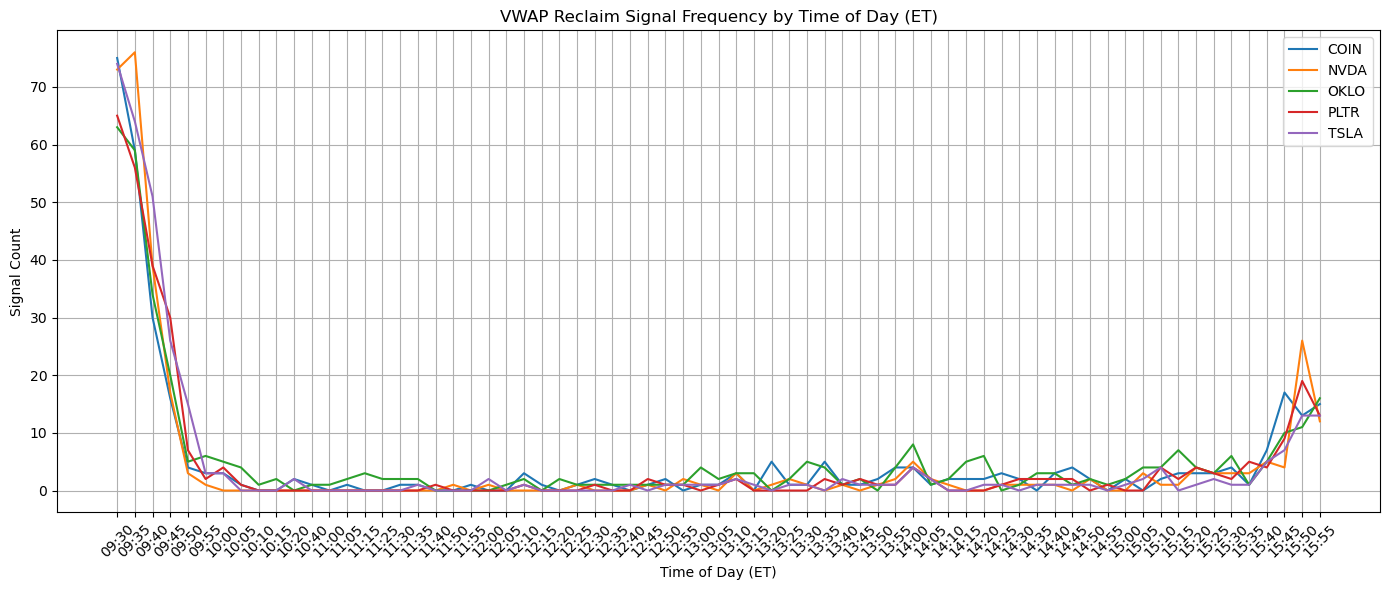

In [21]:
# visualize VWAP Reclaim entries by Time of Day
temp_entries = entries.copy()
temp_entries["hour_min"] = (
    pd.to_datetime(temp_entries["ts_signal"], utc=True)
    .dt.tz_convert("America/New_York")
    .dt.strftime("%H:%M")
)

entry_tod = (
    temp_entries.groupby(["symbol", "hour_min"])
    .size()
    .reset_index(name="count")
)

all_times = sorted(entry_tod["hour_min"].unique())

plt.figure(figsize=(14, 6))
for sym in sorted(entry_tod["symbol"].unique()):
    d = (
        entry_tod[entry_tod["symbol"] == sym]
        .set_index("hour_min")["count"]
        .reindex(all_times, fill_value=0)
    )
    plt.plot(d.index, d.values, label=sym)

plt.title("VWAP Reclaim Signal Frequency by Time of Day (ET)")
plt.xlabel("Time of Day (ET)")
plt.ylabel("Signal Count")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There are 1616 VWAP reclaim trade opportunities between OKLO, COIN, TSLA, NVDA, & PLTR.

### Trade Simulator and Follow-Through Analysis

In [22]:
# compute MFE and MAE

# set 2 hour window
FORWARD_BARS = 24

def compute_mfe_mae(df, i_entry, forward_bars=FORWARD_BARS):
    entry_row   = df.iloc[i_entry]
    entry_price = entry_row['open']
    atr         = entry_row['atr_12']
    symbol      = entry_row['symbol']
    date        = entry_row['date_ny']

    if atr <= 0 or pd.isna(atr):
        return None
    # forward window current trading session only
    window = df.iloc[i_entry : i_entry + forward_bars + 1]
    window = window[(window['symbol'] == symbol) & (window['date_ny'] == date)]

    if len(window) < 2:
        return None

    highs = window['high'].values
    lows  = window['low'].values

    mfe_atr        = (highs.max() - entry_price) / atr
    mae_atr        = (entry_price - lows.min()) / atr
    time_to_peak   = int(highs.argmax())

    return {
        'mfe_atr':           round(mfe_atr, 4),
        'mae_atr':           round(mae_atr, 4),
        'time_to_peak_bars': time_to_peak
    }

# run for all VWAP Reclaim trades
mfe_results = []
for _, row in entries.iterrows():
    result = compute_mfe_mae(df, int(row['i_entry']))
    if result:
        mfe_results.append(result)
    else:
        mfe_results.append({'mfe_atr': None, 'mae_atr': None, 'time_to_peak_bars': None})

mfe_df = pd.DataFrame(mfe_results)
entries = entries.reset_index(drop=True)
entries[['mfe_atr', 'mae_atr', 'time_to_peak_bars']] = mfe_df[['mfe_atr', 'mae_atr', 'time_to_peak_bars']]

print(f"MFE/MAE computed: {entries['mfe_atr'].notna().sum()} of {len(entries)} entries")
print(f"\nMFE distribution (ATR units):")
print(entries['mfe_atr'].describe().round(3))
print(f"\nMAE distribution (ATR units):")
print(entries['mae_atr'].describe().round(3))

MFE/MAE computed: 1534 of 1616 entries

MFE distribution (ATR units):
count    1534.000
mean        2.552
std         2.683
min         0.000
25%         0.848
50%         1.903
75%         3.344
max        41.749
Name: mfe_atr, dtype: float64

MAE distribution (ATR units):
count    1534.000
mean        2.433
std         2.191
min         0.000
25%         0.857
50%         1.844
75%         3.419
max        16.814
Name: mae_atr, dtype: float64


Distribution of MFE and MAE appear to be almost identical. This indicates that edge is not in the setup but rather in the parameters utilized.

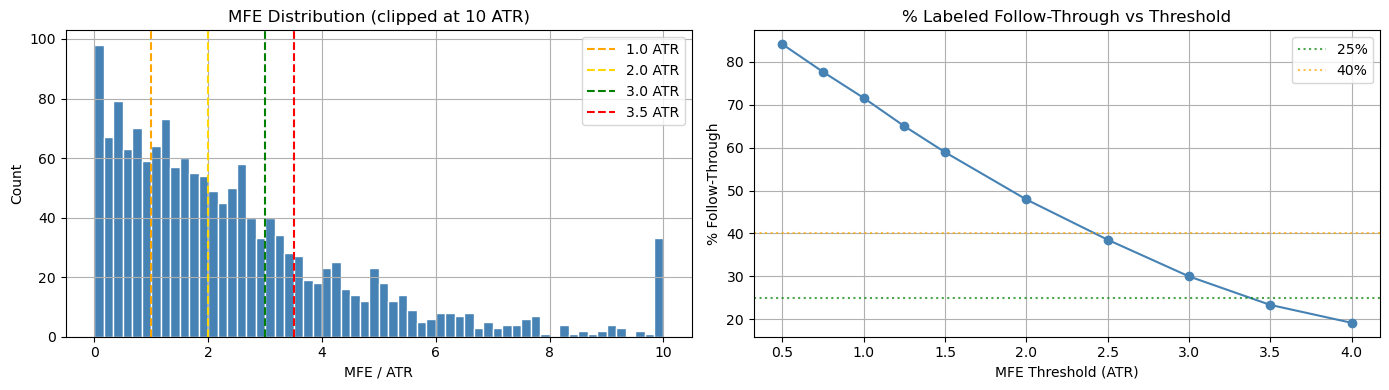

 Threshold     % FT   Count FT   Count Not FT
      0.50    84.1%       1290            244
      0.75    77.6%       1191            343
      1.00    71.6%       1098            436
      1.25    65.0%        997            537
      1.50    58.9%        904            630
      2.00    47.9%        735            799
      2.50    38.5%        591            943
      3.00    30.0%        460           1074
      3.50    23.3%        358           1176
      4.00    19.2%        294           1240


In [23]:
# follow through analysis

# plot distribution to visualize
valid = entries.dropna(subset=['mfe_atr'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# mfe plot
axes[0].hist(valid['mfe_atr'].clip(upper=10), bins=60,
             color='steelblue', edgecolor='white')
axes[0].axvline(1.0, color='orange', linestyle='--', linewidth=1.5, label='1.0 ATR')
axes[0].axvline(2.0, color='gold',   linestyle='--', linewidth=1.5, label='2.0 ATR')
axes[0].axvline(3.0, color='green',  linestyle='--', linewidth=1.5, label='3.0 ATR')
axes[0].axvline(3.5, color='red',    linestyle='--', linewidth=1.5, label='3.5 ATR')
axes[0].set_title('MFE Distribution (clipped at 10 ATR)')
axes[0].set_xlabel('MFE / ATR')
axes[0].set_ylabel('Count')
axes[0].legend()

# follow through vs threshold plot
thresholds = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0]
pct_ft = [(valid['mfe_atr'] >= t).mean() * 100 for t in thresholds]

axes[1].plot(thresholds, pct_ft, marker='o', color='steelblue')
axes[1].axhline(25, color='green', linestyle=':', alpha=0.7, label='25%')
axes[1].axhline(40, color='orange', linestyle=':', alpha=0.7, label='40%')
axes[1].set_title('% Labeled Follow-Through vs Threshold')
axes[1].set_xlabel('MFE Threshold (ATR)')
axes[1].set_ylabel('% Follow-Through')
axes[1].legend()

plt.tight_layout()
plt.show()

# threshold table
print(f"{'Threshold':>10} {'% FT':>8} {'Count FT':>10} {'Count Not FT':>14}")
for t, pct in zip(thresholds, pct_ft):
    n_ft  = (valid['mfe_atr'] >= t).sum()
    n_nft = (valid['mfe_atr'] < t).sum()
    print(f"{t:>10.2f} {pct:>7.1f}% {n_ft:>10} {n_nft:>14}")

At 3 ATR, only about 30% of trades hit this threshold. This gives a good signal as a home run trade for follow through.

For follow through trades, the signal is to hold for larger profits.

In [24]:
# follow through binary label

# define follow through as 3 ATR
FT_THRESHOLD = 3.0

entries['follow_through'] = (entries['mfe_atr'] >= FT_THRESHOLD).astype(int)

# validate follow through
ft      = entries['follow_through'] == 1
n_total = entries['follow_through'].notna().sum()
n_ft    = ft.sum()
n_nft   = (~ft).sum()

print(f"Follow-Through threshold : {FT_THRESHOLD} ATR")
print(f"Follow-Through (Hold)    : {n_ft}  ({n_ft/n_total*100:.1f}%)")
print(f"No Follow-Through (Scalp): {n_nft} ({n_nft/n_total*100:.1f}%)")

print(f"\nMFE by class:")
print(entries.groupby('follow_through')['mfe_atr'].describe().round(3))

print(f"\nMAE by class:")
print(entries.groupby('follow_through')['mae_atr'].describe().round(3))

print(f"\nBy symbol:")
print(entries.groupby(['symbol','follow_through']).size().unstack(fill_value=0))

Follow-Through threshold : 3.0 ATR
Follow-Through (Hold)    : 460  (28.5%)
No Follow-Through (Scalp): 1156 (71.5%)

MFE by class:
                 count   mean    std    min    25%    50%    75%     max
follow_through                                                          
0               1074.0  1.316  0.858  0.000  0.576  1.250  2.011   2.982
1                460.0  5.435  3.228  3.003  3.568  4.486  6.040  41.749

MAE by class:
                 count   mean    std  min    25%    50%    75%     max
follow_through                                                        
0               1074.0  2.910  2.237  0.0  1.251  2.383  4.017  15.048
1                460.0  1.321  1.603  0.0  0.390  0.886  1.660  16.814

By symbol:
follow_through    0    1
symbol                  
COIN            238   91
NVDA            228   78
OKLO            238  122
PLTR            210   92
TSLA            242   77


Follow through trades barely dip before they move in favorable direction. Non follow through trades go against you before reversing.

In [25]:
# Trade simulation

SCALP_MODE = {"stop_atr": 0.5,  "target_atr": 0.75, "hold_bars": 6,  "risk_per_trade": 750}
HOLD_MODE  = {"stop_atr": 1.0,  "target_atr": 2.5,  "hold_bars": 24, "risk_per_trade": 1500}

# simulate a long trade
def simulate_one_entry_long(df, i_entry, stop_atr, target_atr, hold_bars, **kwargs):
    entry_row   = df.iloc[i_entry]
    entry_price = entry_row['open']
    atr         = entry_row['atr_12']
    symbol      = entry_row['symbol']
    date        = entry_row['date_ny']

    risk         = stop_atr * atr
    stop_price   = entry_price - risk
    target_price = entry_price + target_atr * atr

    if risk <= 0:
        return None

    # forward price bars
    window = df.iloc[i_entry : i_entry + hold_bars + 1]
    window = window[(window['symbol'] == symbol) & (window['date_ny'] == date)]

    exit_price  = None
    exit_reason = None

    for _, bar in window.iterrows():
        if bar['low'] <= stop_price:
            exit_price  = stop_price
            exit_reason = 'STOP'
            break
        elif bar['high'] >= target_price:
            exit_price  = target_price
            exit_reason = 'TARGET'
            break

    if exit_price is None:
        exit_price  = window.iloc[-1]['close']
        exit_reason = 'TIME'

    R = (exit_price - entry_price) / risk

    return {'R': round(R, 4), 'exit_reason': exit_reason, 'exit_price': round(exit_price, 4)}

# run simulation
scalp_results  = []
hold_results   = []

for _, row in entries.iterrows():
    i = int(row['i_entry'])
    scalp_results.append(simulate_one_entry_long(df, i, **SCALP_MODE))
    hold_results.append(simulate_one_entry_long(df, i, **HOLD_MODE))

scalp_df = pd.DataFrame(scalp_results).add_prefix('scalp_')
hold_df  = pd.DataFrame(hold_results).add_prefix('hold_')

entries = entries.reset_index(drop=True)
entries[['R_scalp', 'exit_reason_scalp', 'exit_price_scalp']] = scalp_df[['scalp_R', 'scalp_exit_reason', 'scalp_exit_price']]
entries[['R_hold',  'exit_reason_hold',  'exit_price_hold']]  = hold_df[['hold_R',  'hold_exit_reason',  'hold_exit_price']]

# Oracle trade
entries['R_oracle']           = entries.apply(lambda r: r['R_hold']  if r['follow_through'] == 1 else r['R_scalp'], axis=1)
entries['risk_oracle']        = entries.apply(lambda r: HOLD_MODE['risk_per_trade'] if r['follow_through'] == 1 else SCALP_MODE['risk_per_trade'], axis=1)
entries['exit_reason_oracle'] = entries.apply(lambda r: r['exit_reason_hold'] if r['follow_through'] == 1 else r['exit_reason_scalp'], axis=1)

# summary details
print("Scalp Mode (stop 0.5 ATR, target 0.75 ATR, hold 6 bars, $750 risk)")
print(entries['R_scalp'].describe().round(3))
print(entries['exit_reason_scalp'].value_counts())

print("\nHold Mode (stop 1.0 ATR, target 2.5 ATR, hold 24 bars, $1500 risk)")
print(entries['R_hold'].describe().round(3))
print(entries['exit_reason_hold'].value_counts())

print("\nOracle (perfect follow-through prediction)")
entries['pnl_oracle'] = entries['R_oracle'] * entries['risk_oracle']
print(f"Total Oracle P&L : ${entries['pnl_oracle'].sum():,.0f}")
print(f"Mean R (oracle)  : {entries['R_oracle'].mean():.3f}")
print(entries['exit_reason_oracle'].value_counts())

Scalp Mode (stop 0.5 ATR, target 0.75 ATR, hold 6 bars, $750 risk)
count    1616.000
mean       -0.084
std         1.198
min        -1.000
25%        -1.000
50%        -1.000
75%         1.500
max         1.500
Name: R_scalp, dtype: float64
exit_reason_scalp
STOP      1012
TARGET     583
TIME        21
Name: count, dtype: int64

Hold Mode (stop 1.0 ATR, target 2.5 ATR, hold 24 bars, $1500 risk)
count    1616.000
mean        0.037
std         1.493
min        -1.000
25%        -1.000
50%        -1.000
75%         1.703
max         2.500
Name: R_hold, dtype: float64
exit_reason_hold
STOP      1014
TARGET     383
TIME       219
Name: count, dtype: int64

Oracle (perfect follow-through prediction)
Total Oracle P&L : $649,836
Mean R (oracle)  : 0.188
exit_reason_oracle
STOP      953
TARGET    642
TIME       21
Name: count, dtype: int64


### Finalize VWAP Reclaim Trades

In [26]:
# merge entries to price data
feature_cols = [
    'timestamp', 'date_ny',
    'ret_1', 'ret_3', 'ret_6', 'ret_12', 'ret_18', 'ret_24',
    'atr_12', 'atr_pct_12',
    'vwap_dist', 'vwap_dist_atr',
    'vol_ratio_18', 'rv_12',
    'range_pct', 'body_pct', 'upper_wick_pct', 'lower_wick_pct',
    'tod_sin', 'tod_cos'
]

signal_features = df.iloc[entries['i_signal'].values][feature_cols].reset_index(drop=True)
entries = pd.concat([entries.reset_index(drop=True), signal_features], axis=1)

entries['entry_atr'] = df.iloc[entries['i_entry'].values]['atr_12'].values
entries['side'] = 'LONG'

print(entries.columns.tolist())

['symbol', 'i_signal', 'i_entry', 'ts_signal', 'ts_entry', 'entry_price', 'mfe_atr', 'mae_atr', 'time_to_peak_bars', 'follow_through', 'R_scalp', 'exit_reason_scalp', 'exit_price_scalp', 'R_hold', 'exit_reason_hold', 'exit_price_hold', 'R_oracle', 'risk_oracle', 'exit_reason_oracle', 'pnl_oracle', 'timestamp', 'date_ny', 'ret_1', 'ret_3', 'ret_6', 'ret_12', 'ret_18', 'ret_24', 'atr_12', 'atr_pct_12', 'vwap_dist', 'vwap_dist_atr', 'vol_ratio_18', 'rv_12', 'range_pct', 'body_pct', 'upper_wick_pct', 'lower_wick_pct', 'tod_sin', 'tod_cos', 'entry_atr', 'side']


In [27]:
entries.head()

,symbol,i_signal,i_entry,ts_signal,ts_entry,entry_price,mfe_atr,mae_atr,time_to_peak_bars,follow_through,...,vol_ratio_18,rv_12,range_pct,body_pct,upper_wick_pct,lower_wick_pct,tod_sin,tod_cos,entry_atr,side
0,COIN,48,49,2024-02-29 14:30:00,2024-02-29 14:35:00,209.720,0.3325,6.5316,0.0,0,...,5.231263,0.013304,0.027496,0.014417,0.008736,0.004344,0.000000,1.000000,2.285808,LONG
1,COIN,117,118,2024-02-29 20:15:00,2024-02-29 20:20:00,201.420,2.8474,0.1382,7.0,0,...,1.819754,0.003376,0.006452,0.003375,0.002531,0.000546,-0.663123,0.748511,1.085183,LONG
2,COIN,283,284,2024-03-05 14:35:00,2024-03-05 14:40:00,233.650,1.8685,4.6165,5.0,0,...,2.044270,0.011639,0.032817,0.025244,0.003295,0.004279,0.080467,0.996757,3.387817,LONG
3,COIN,360,361,2024-03-06 14:30:00,2024-03-06 14:35:00,233.055,0.4519,3.1354,1.0,0,...,3.736540,0.021586,0.028907,0.016984,0.007934,0.003989,0.000000,1.000000,3.197400,LONG
4,COIN,578,579,2024-03-08 19:40:00,2024-03-08 19:45:00,257.810,0.8801,2.2621,3.0,0,...,1.805014,0.003391,0.008245,0.007876,0.000272,0.000097,-0.960518,0.278217,1.454400,LONG


In [28]:
# split data
entries['date_ny'] = pd.to_datetime(entries['date_ny'])

sorted_dates = sorted(entries['date_ny'].unique())
train_end = sorted_dates[int(len(sorted_dates) * 0.70) - 1]
val_end   = sorted_dates[int(len(sorted_dates) * 0.85) - 1]

def assign_split(d):
    if d <= train_end:
        return 'train'
    elif d <= val_end:
        return 'val'
    else:
        return 'test'

entries['split'] = entries['date_ny'].apply(assign_split)

print("Split distribution:")
print(entries['split'].value_counts().sort_index())
print(f"\nTrain end : {train_end.date()}")
print(f"Val end   : {val_end.date()}")

# file columns
output_cols = [
    # identifiers
    'symbol', 'timestamp', 'date_ny', 'i_signal', 'i_entry', 'ts_signal', 'ts_entry',
    'entry_price', 'entry_atr', 'side', 'split',
    # input features
    'ret_1', 'ret_3', 'ret_6', 'ret_12', 'ret_18', 'ret_24',
    'atr_12', 'atr_pct_12',
    'vwap_dist', 'vwap_dist_atr',
    'vol_ratio_18', 'rv_12',
    'range_pct', 'body_pct', 'upper_wick_pct', 'lower_wick_pct',
    'tod_sin', 'tod_cos',
    # forward simulation
    'mfe_atr', 'mae_atr', 'time_to_peak_bars',
    # target
    'follow_through',
    # mode simulation results
    'R_scalp', 'exit_reason_scalp',
    'R_hold',  'exit_reason_hold',
    # oracle
    'R_oracle', 'risk_oracle', 'exit_reason_oracle',
]

# validate and save
missing = [c for c in output_cols if c not in entries.columns]
if missing:
    print(f"missing columns: {missing}")
else:
    entries[output_cols].to_csv('multiasset_labeled_entries.csv', index=False)
    print(f"Saved {len(entries)} entries to multiasset_labeled_entries.csv")
    print(f"\nlabel distribution:")
    print(entries['follow_through'].value_counts())
    print(f"\nOracle P&L ceiling: ${(entries['R_oracle'] * entries['risk_oracle']).sum():,.0f}")

Split distribution:
split
test      251
train    1112
val       253
Name: count, dtype: int64

Train end : 2025-07-08
Val end   : 2025-10-22
Saved 1616 entries to multiasset_labeled_entries.csv

label distribution:
follow_through
0    1156
1     460
Name: count, dtype: int64

Oracle P&L ceiling: $649,836


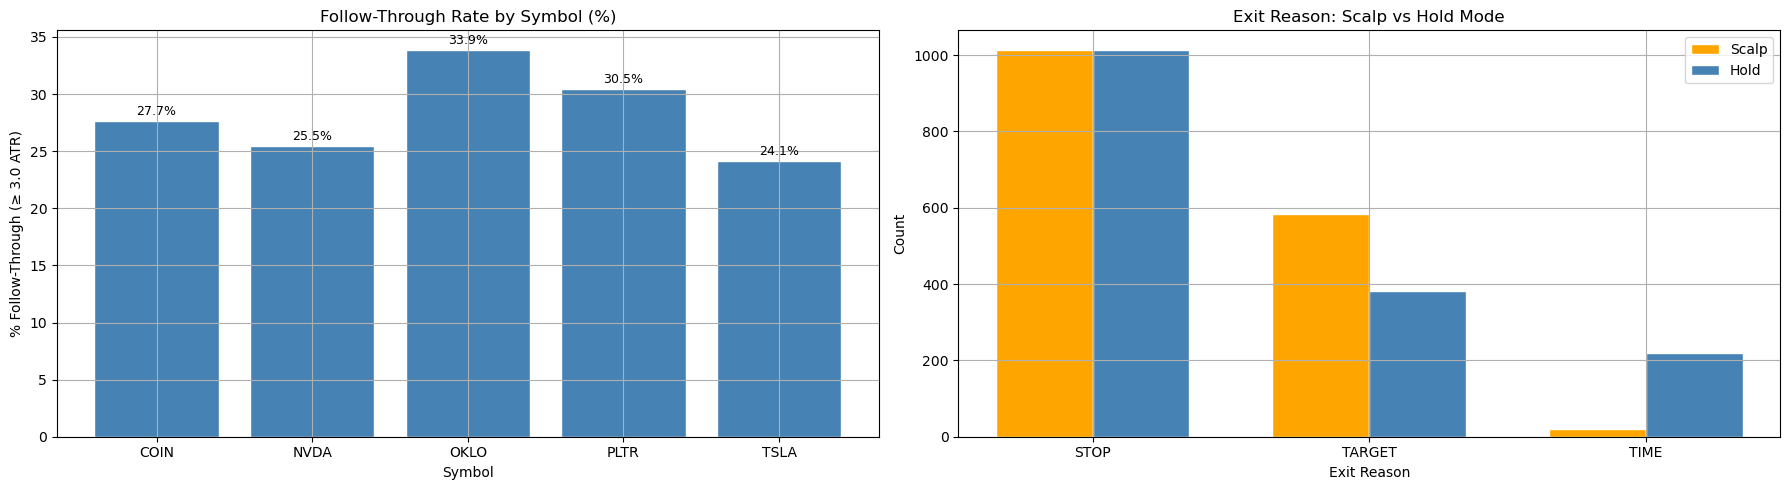

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# follow through rate plot
ft_by_symbol = entries.groupby('symbol')['follow_through'].mean() * 100
axes[0].bar(ft_by_symbol.index, ft_by_symbol.values, color='steelblue', edgecolor='white')
axes[0].set_title('Follow-Through Rate by Symbol (%)')
axes[0].set_xlabel('Symbol')
axes[0].set_ylabel('% Follow-Through (≥ 3.0 ATR)')
for i, v in enumerate(ft_by_symbol.values):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

# exit reason plot
exit_scalp = entries['exit_reason_scalp'].value_counts()
exit_hold  = entries['exit_reason_hold'].value_counts()
x = range(len(exit_scalp))
width = 0.35
axes[1].bar([i - width/2 for i in x], exit_scalp.values, width, label='Scalp', color='orange', edgecolor='white')
axes[1].bar([i + width/2 for i in x], [exit_hold.get(k, 0) for k in exit_scalp.index], width, label='Hold', color='steelblue', edgecolor='white')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(exit_scalp.index)
axes[1].set_title('Exit Reason: Scalp vs Hold Mode')
axes[1].set_xlabel('Exit Reason')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()
